# Notebook 05 — DCGAN on STL-10

**Generative Models — From Scratch**

Continuing Notebook 04 (Vanilla GAN on Olivetti Faces), this notebook answers:

> **Why do convolutional architectures make GANs much better suited for image generation?**

## 1. Introduction — Recap of Vanilla GAN

In Notebook 04 we built the classic adversarial game:

```text
Generator:     z (latent vector)  ->  fake image
Discriminator: image              ->  real / fake score
```

The two networks behave like a **counterfeiter** (Generator) and a
**detective** (Discriminator): each improves by playing against the other.

Both were **MLPs (fully connected)**. For images this is awkward:

| Vanilla GAN view | Reality of images |
|---|---|
| Image = one long vector | Image = 2D grid of RGB pixels |
| Neighboring pixels are unrelated coordinates | Neighbors form edges, textures, objects |
| Parameters grow with every pixel | Local patterns repeat everywhere |

Real images are **hierarchical spatial structures**:

```text
neighboring pixels -> local patterns -> edges -> textures -> parts -> objects
```

A CNN is designed exactly to exploit this hierarchy. That is the idea behind **DCGAN**.

This notebook is fully self-contained (nothing is loaded from other notebooks).

## 2. Dataset — STL-10

We use **STL-10**: RGB natural images (96 x 96) from 10 object categories
(airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck).

Compared to Olivetti Faces (Notebook 04), STL-10 offers far more visual
diversity: natural scenes, rich textures, many colors — a much more
interesting test for convolutional generation.

We resize to **64
interesting test for convolutional generation.

We resize to **64 architecture,
- 64 = 2^6 gives a clean spatial progression for transposed convolutions,
- still enough structure to demonstrate convolutional generation.

In [19]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

Device: cuda


## 3. Data Preprocessing

- `Resize((64, 64))`: 96x96 -> 64x64.
- `ToTensor()`: pixels from `[0, 255]` to `[0, 1]`.
- `Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))`: maps `[0, 1]` to `[-1, 1]`.

The normalization to `[-1, 1]` **must match** the Generator's final `Tanh`.
Final tensor format: `[B, 3, 64, 64]`. We use `num_workers=0` for portability.

In [20]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = datasets.STL10(root="./data/STL-10", split="train", transform=transform, download=True)

BATCH_SIZE = 64
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

image, label = dataset[0]
print("Number of images:", len(dataset))
print("Sample tensor shape (after transform):", tuple(image.shape))
print("Channels:", image.shape[0], "| per-image size:", tuple(image.shape[1:]))
print("Pixel range after normalization: [", image.min().item(), ",", image.max().item(), "]")
print("Classes (labels):", dataset.classes if hasattr(dataset, "classes") else "not exposed")
print("Label of sample 0:", label)

Number of images: 5000
Sample tensor shape (after transform): (3, 64, 64)
Channels: 3 | per-image size: (64, 64)
Pixel range after normalization: [ -0.8980392217636108 , 0.9529411792755127 ]
Classes (labels): ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Label of sample 0: 1


Before any plotting or sampling, we define small reusable helpers:

- `show_images` — displays a batch in `[-1, 1]` after unnormalizing to `[0, 1]`,
  uses `.detach().cpu()`, handles RGB (HWC permute), and does not rely on `torchvision.utils`.
- `count_parameters` — total trainable parameter count.
- `generate_samples` — sample images from random latent vectors.

Real batch shape: (64, 3, 64, 64) | first labels: [6, 6, 6, 4, 0, 1, 0, 7]


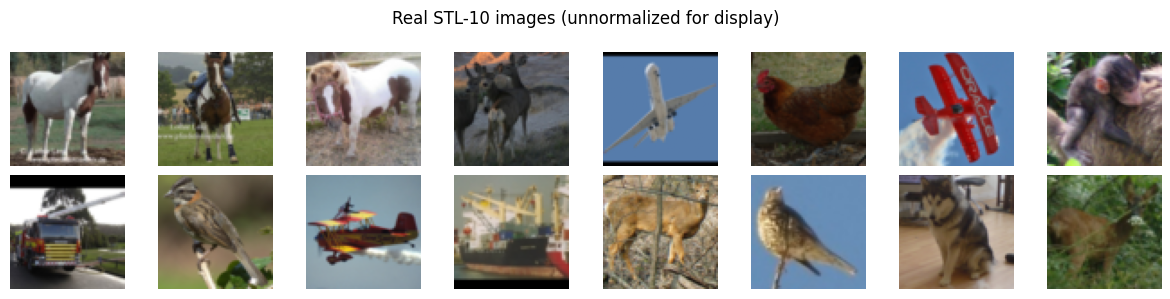

In [38]:
def show_images(images, title=None, nrow=8, figsize=None):
    """Show a grid of RGB images stored in [-1, 1] (unnormalized for display)."""
    images = images.detach().cpu()
    images = ((images + 1) / 2).clamp(0, 1)   # [-1, 1] -> [0, 1]
    n = images.shape[0]
    nrow = min(nrow, n)
    rows = (n + nrow - 1) // nrow
    figsize = figsize or (nrow * 1.5, rows * 1.5)
    fig, axes = plt.subplots(rows, nrow, figsize=figsize)
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(images[i].permute(1, 2, 0).numpy())  # [C,H,W] -> [H,W,C]
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def generate_samples(generator, n, device=DEVICE):
    """Generate n images using the latent dimension expected by G."""

    generator_was_training = generator.training
    generator.eval()

    # Read latent dimension directly from the first Linear layer
    latent_dim = generator.project[0].in_features

    z = torch.randn(
        n,
        latent_dim,
        device=device
    )

    with torch.no_grad():
        fake = generator(z)

    generator.train(generator_was_training)

    return fake


real_batch, real_labels = next(iter(loader))
print("Real batch shape:", tuple(real_batch.shape), "| first labels:", real_labels[:8].tolist())
show_images(real_batch[:16], title="Real STL-10 images (unnormalized for display)", nrow=8)

## 4. Why Vanilla GAN Struggles With Images

**Vanilla Generator** (MLP):

```text
z -> Linear -> Linear -> Linear -> 4096 values -> reshape -> 64 x 64 image
```

Limitations:

- huge parameter count (every output pixel connected to every input),
- **no spatial inductive bias**: neighboring pixels are not treated specially,
- image structure (edges, textures) must be learned from scratch,
- parameter count grows quickly with image size.

**Vanilla Discriminator** (MLP):

```text
3 x 64 x 64 -> Flatten -> 12288 -> Linear layers
```

> Flattening an image turns a spatial structure into a long vector: shifting the
> image by one pixel changes every input coordinate.

This does **not** mean MLPs can never generate images — they can, inefficiently.
CNNs are simply a **much more natural architecture** for image data.

## 5. What Is DCGAN?

**DCGAN** (Deep Convolutional GAN) replaces the major MLP blocks with
convolutional operations:

```text
Generator:     latent -> Linear -> 4x4 feature map -> ConvTranspose2d x4 -> RGB image
Discriminator: RGB image -> Conv2d x4 -> 4x4 features -> Linear -> 1 logit
```

Core transition:

```text
Vanilla GAN: treats an image as a long vector
DCGAN:       treats an image as a spatial structure

## 6. Tensor Shape Intuition

Constants used throughout:

```python
LATENT_DIM = 100
FEATURES_G = 64
FEATURES_D = 64
IMAGE_SIZE = 64
```

Generator shape flow:

```text
z                        [B, 100]
Linear(100 -> 4*4*512)   [B, 8192]
reshape                  [B, 512, 4, 4]
ConvTranspose2d  4 -> 8  [B, 256, 8, 8]
ConvTranspose2d  8 -> 16 [B, 128, 16, 16]
ConvTranspose2d 16 -> 32 [B,  64, 32, 32]
ConvTranspose2d 32 -> 64 [B,   3, 64, 64]
```

Each `ConvTranspose2d(kernel_size=4, stride=2, padding=1)` doubles the size:

```text
out = (in - 1)*stride - 2*padding + kernel_size = (in - 1)*2 + 2 = 2*in
```

so **4 -> 8 -> 16 -> 32 -> 64** happens automatically.

## 7. Transposed Convolution

A **transposed convolution** (`nn.ConvTranspose2d`) is a *learned* layer whose
output spatial size can be **larger** than its input — the standard upsampling
tool in generators.

It is **not** simply "the exact opposite of convolution". Conceptually it
transposes the convolution's connectivity pattern: small learned contributions
are spread over a larger map, and the layer learns *how* to combine them.

```text
latent code
      |
small feature map    (4 x 4, 512 ch)
      | ConvTranspose2d
larger feature map   (8 x 8, 256 ch)
      | ConvTranspose2d
      ...
image                (64 x 64, 3 ch)
```

## 8. DCGAN Generator

In [22]:
LATENT_DIM = 100
FEATURES_G = 64
FEATURES_D = 64
IMAGE_SIZE = 64


class Generator(nn.Module):
    """Classic DCGAN generator: latent vector -> [B, 3, 64, 64] image in [-1, 1]."""
    def __init__(self, latent_dim=LATENT_DIM, features=FEATURES_G):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 4 * 4 * 512),
            nn.BatchNorm1d(4 * 4 * 512),
            nn.ReLU(inplace=True),
        )
        self.conv = nn.Sequential(
            # [512, 4, 4] -> [256, 8, 8]
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # [256, 8, 8] -> [128, 16, 16]
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # [128, 16, 16] -> [64, 32, 32]
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # [64, 32, 32] -> [3, 64, 64]  (no BatchNorm on the final layer)
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        out = self.project(z)
        out = out.reshape(out.shape[0], 512, 4, 4)  # reshape (not view)
        return self.conv(out)


G = Generator().to(DEVICE)
print(G)
print("Generator parameters:", count_parameters(G))

# shape flow demonstration
with torch.no_grad():
    z = torch.randn(4, LATENT_DIM, device=DEVICE)
    print("z:", tuple(z.shape))
    print("after Linear+reshape:", tuple(G.project(z).reshape(4, 512, 4, 4).shape))
    print("G(z):", tuple(G(z).shape))

Generator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh(

## 9. Why BatchNorm?

BatchNorm normalizes each layer's activations during training. In GANs this helps because:

- it keeps intermediate activation distributions well-behaved while both networks move,
- it makes optimization easier and less sensitive to initialization,
- it supports stable training of deep deconvolutional stacks (the classic DCGAN recipe).

Where it appears:

```text
ConvTranspose2d -> BatchNorm2d -> ReLU
```

**The final Generator layer is an exception** — no BatchNorm:

```text
ConvTranspose2d -> Tanh
```

BatchNorm right before the output would constrain the output distribution and
interfere with producing the full `[-1, 1]` range. This is a practical choice,
not a guarantee of stability.

## 10. Why ReLU in the Generator?

ReLU provides the nonlinear steps needed to build a feature hierarchy:

```text
latent information -> low-level structure -> mid-level structure -> high-level structure -> image
```

ReLU is simple, trains fast, and does not saturate like sigmoid/tanh, so
gradients flow easily through many stacked transposed convolutions.

## 11. DCGAN Discriminator

In [23]:
class Discriminator(nn.Module):
    """Classic DCGAN discriminator: [B, 3, 64, 64] -> [B, 1] logit (NO Sigmoid)."""
    def __init__(self, features=FEATURES_D):
        super().__init__()
        self.net = nn.Sequential(
            # [3, 64, 64] -> [64, 32, 32]  (classic DCGAN: no BatchNorm on first conv)
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # [64, 32, 32] -> [128, 16, 16]
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # [128, 16, 16] -> [256, 8, 8]
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # [256, 8, 8] -> [512, 4, 4]
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.Linear(512 * 4 * 4, 1)  # raw logit

    def forward(self, x):
        out = self.net(x)
        out = out.reshape(out.shape[0], -1)
        return self.classifier(out)


D = Discriminator().to(DEVICE)
print(D)
print("Discriminator parameters:", count_parameters(D))
print("D(real_batch):", tuple(D(real_batch[:4].to(DEVICE)).shape))

Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (classifier): Linear(in_features=8192, out_features=1, bias=True)
)
Discriminator parameters: 2765569
D(real_batch): (4, 1)

## 12. Why LeakyReLU?

The Discriminator uses `nn.LeakyReLU(0.2)`: negative inputs pass with a small
slope (`0.2 * x`) instead of being clipped to zero.

> During adversarial training we do not want neurons to become permanently
> inactive just because their pre-activation is negative.

Dead ReLU units stop contributing gradients — and G's updates depend on gradients
flowing *through* D. LeakyReLU keeps those pathways weakly alive. A practical
design choice, not a universal law.

## 13. Classic DCGAN Design Principles

- Convolutions instead of large fully-connected blocks.
- **ConvTranspose2d** in the Generator (learned upsampling).
- **BatchNorm** in intermediate layers (except G output, D first layer).
- **ReLU** in the Generator; **LeakyReLU** in the Discriminator.
- **Tanh** at the Generator output, matching `[-1, 1]` data normalization.
- **No pooling layers** — strided convolutions learn how to change resolution.

## 14. Build the GAN

`build_dcgan()` returns a fresh Generator, Discriminator, their Adam optimizers
(`lr=2e-4, betas=(0.5, 0.999)` — the same scale that worked in Notebook 04) and
`BCEWithLogitsLoss`. We also include the classic DCGAN weight initialization
(normal with std 0.02; BatchNorm weight 1, bias 0).

In [24]:
def weights_init_dcgan(model):
    """Classic DCGAN init: N(0, 0.02) for conv/linear weights, BN weight=1 bias=0."""
    for m in model.modules():
        if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d, nn.Linear)):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)


def build_dcgan():
    generator = Generator().to(DEVICE)
    discriminator = Discriminator().to(DEVICE)
    generator.apply(weights_init_dcgan)
    discriminator.apply(weights_init_dcgan)
    optimizer_G = torch.optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()  # sigmoid + BCE, numerically stable
    return generator, discriminator, optimizer_G, optimizer_D, criterion


G, D, opt_G, opt_D, criterion = build_dcgan()
print("GAN built | G params:", count_parameters(G), "| D params:", count_parameters(D))

GAN built | G params: 3600256 | D params: 2765569


## 15. One Training Step

We manually perform one iteration on a **temporary freshly built GAN** (so the
real one stays clean).

### Discriminator step
1. sample real images, 2. sample noise, 3. generate fake images, 4. evaluate real,
5. evaluate fake, 6. real loss, 7. fake loss, 8. combine, 9. backprop, 10. update D.

`fake_images.detach()` cuts fake images off from the Generator graph so updating
D does **not** backpropagate into G. Targets are `1` for real, `0` for fake on
raw logits (`BCEWithLogitsLoss` applies the sigmoid internally).

### Generator step
New noise -> G -> D with **D's parameter gradients temporarily disabled**, while
the graph `G -> fake image -> D` remains intact so the loss gradient reaches G.
G's target is "real" (G wants to fool D). D's `requires_grad` is always restored.

In [25]:
# --- temporary GAN used only to demonstrate one step ---
G_tmp, D_tmp, optG_tmp, optD_tmp, criterion = build_dcgan()

real_images = real_batch.to(DEVICE)

# ---------- Discriminator step ----------
optD_tmp.zero_grad()
fake_images = G_tmp(torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE))

real_preds = D_tmp(real_images)
fake_preds = D_tmp(fake_images.detach())            # detach: stop gradients before G

real_targets = torch.ones_like(real_preds)          # real  -> 1
fake_targets = torch.zeros_like(fake_preds)         # fake  -> 0

d_loss = criterion(real_preds, real_targets) + criterion(fake_preds, fake_targets)
d_loss.backward()
optD_tmp.step()

# ---------- Generator step ----------
optG_tmp.zero_grad()
D_tmp.requires_grad_(False)                         # freeze D parameters temporarily

fake_images = G_tmp(torch.randn(BATCH_SIZE, LATENT_DIM, device=DEVICE))
g_preds = D_tmp(fake_images)                        # graph G -> fake -> D stays intact
g_loss = criterion(g_preds, torch.ones_like(g_preds))  # G's target = "real"

g_loss.backward()
optG_tmp.step()
D_tmp.requires_grad_(True)                          # always restore D

print(f"D loss: {d_loss.item():.4f} | G loss: {g_loss.item():.4f}")
print("One step done on the temporary GAN (no real training performed yet).")

D loss: 1.9562 | G loss: 4.2088
One step done on the temporary GAN (no real training performed yet).


## 16. Training Configuration

Default educational configuration. `RUN_TRAINING=False` is a clearly marked
**runtime guard**: the notebook stays practical top-to-bottom and shows
explicitly labeled **demo / untrained** outputs. Set it to `True` to run the
full training (long, especially on CPU).

In [26]:
SEED = 42
LATENT_DIM = 100
IMAGE_SIZE = 64
CHANNELS = 3
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 2e-4
BETAS = (0.5, 0.999)
IMAGE_SAMPLES = 16
SNAPSHOT_EPOCHS = [0, 1, 5, 10, 20, 30, 40, 50]

RUN_TRAINING = True  # <-- set True to run the FULL 50-epoch DCGAN training

print("RUN_TRAINING =", RUN_TRAINING, "| EPOCHS =", EPOCHS, "| DEVICE =", DEVICE)

RUN_TRAINING = True | EPOCHS = 50 | DEVICE = cuda


## 17. Fixed Latent Vectors

`fixed_noise` is created once and reused at every checkpoint. Any change in the
generated images then comes purely from the Generator changing:

```text
same z -> different checkpoints -> directly observable Generator evolution
```

In [27]:
torch.manual_seed(SEED)
fixed_noise = torch.randn(IMAGE_SAMPLES, LATENT_DIM, device=DEVICE)
print("fixed_noise:", tuple(fixed_noise.shape))

fixed_noise: (16, 100)


## 18. Full Training Loop

`train_dcgan` performs explicit, separate D and G updates per batch, records
histories (`generator_losses`, `discriminator_losses`,
`discriminator_real_scores`, `discriminator_fake_scores`), takes fixed-noise
snapshots at epochs 0, 1, 5, 10, 20, 30, 40, 50 with `torch.no_grad()`, uses
`.detach()` and correct device placement, and **always restores D's
`requires_grad=True`** after the G step. No Sigmoid anywhere.

If `RUN_TRAINING=False`, the next cell rebuilds a clean GAN and creates
**clearly labeled demo fallback** histories (`np.nan`) and snapshots so every
later cell runs without undefined variables.

In [28]:
def train_dcgan(generator, discriminator, optimizer_G, optimizer_D, criterion,
                loader, epochs=EPOCHS, latent_dim=LATENT_DIM,
                fixed_noise_=fixed_noise, snapshot_epochs=SNAPSHOT_EPOCHS):
    generator.train()
    discriminator.train()
    generator_losses, discriminator_losses = [], []
    discriminator_real_scores, discriminator_fake_scores = [], []
    snapshots = {}

    def take_snapshot(epoch_label):
        with torch.no_grad():
            fake = generator(fixed_noise_)
        snapshots[epoch_label] = fake.detach().cpu()

    take_snapshot(0)  # snapshot before any training

    for epoch in range(1, epochs + 1):
        g_sum, d_sum, real_sum, fake_sum, n_batches = 0.0, 0.0, 0.0, 0.0, 0

        for real_images, _ in loader:
            real_images = real_images.to(DEVICE)
            b = real_images.shape[0]
            real_targets = torch.ones(b, 1, device=DEVICE)
            fake_targets = torch.zeros(b, 1, device=DEVICE)

            # ---- Discriminator update ----
            optimizer_D.zero_grad()
            fake_images = generator(torch.randn(b, latent_dim, device=DEVICE))
            d_real = discriminator(real_images)
            d_fake = discriminator(fake_images.detach())   # cut gradient to G
            d_loss = criterion(d_real, real_targets) + criterion(d_fake, fake_targets)
            d_loss.backward()
            optimizer_D.step()

            # ---- Generator update ----
            optimizer_G.zero_grad()
            discriminator.requires_grad_(False)            # freeze D params
            fake_images = generator(torch.randn(b, latent_dim, device=DEVICE))
            g_preds = discriminator(fake_images)           # G -> fake -> D graph intact
            g_loss = criterion(g_preds, torch.ones_like(g_preds))
            g_loss.backward()
            optimizer_G.step()
            discriminator.requires_grad_(True)             # always restore D

            g_sum += g_loss.item()
            d_sum += d_loss.item()
            real_sum += torch.sigmoid(d_real).mean().item()  # only for diagnostics
            fake_sum += torch.sigmoid(d_fake).mean().item()
            n_batches += 1

        generator_losses.append(g_sum / n_batches)
        discriminator_losses.append(d_sum / n_batches)
        discriminator_real_scores.append(real_sum / n_batches)
        discriminator_fake_scores.append(fake_sum / n_batches)

        if epoch in snapshot_epochs:
            take_snapshot(epoch)

        print(f"Epoch {epoch:3d}/{epochs} | D loss={discriminator_losses[-1]:.4f} | "
              f"G loss={generator_losses[-1]:.4f} | D(real)={discriminator_real_scores[-1]:.3f} "
              f"| D(fake)={discriminator_fake_scores[-1]:.3f}")

    return (generator, discriminator, generator_losses, discriminator_losses,
            discriminator_real_scores, discriminator_fake_scores, snapshots)


# Rebuild a CLEAN GAN (the temporary one above was touched by the demo step)
G, D, opt_G, opt_D, criterion = build_dcgan()

if RUN_TRAINING:
    (G, D, generator_losses, discriminator_losses,
     discriminator_real_scores, discriminator_fake_scores, snapshots) = train_dcgan(
        G, D, opt_G, opt_D, criterion, loader, epochs=EPOCHS)
    history_label = "TRAINED (full training was run)"
else:
    # ---- Safe DEMO fallback: clearly labeled, NOT the result of learning ----
    generator_losses = [np.nan] * EPOCHS
    discriminator_losses = [np.nan] * EPOCHS
    discriminator_real_scores = [np.nan] * EPOCHS
    discriminator_fake_scores = [np.nan] * EPOCHS
    G.eval()
    with torch.no_grad():
        demo_fake = G(fixed_noise).detach().cpu()
    G.train()
    snapshots = {epoch: demo_fake.clone() for epoch in SNAPSHOT_EPOCHS}
    history_label = "DEMO / UNTRAINED (RUN_TRAINING=False) — do NOT interpret as learning"

print("History label:", history_label)
print("Snapshots:", list(snapshots.keys()))

Epoch   1/50 | D loss=0.7901 | G loss=14.2221 | D(real)=0.814 | D(fake)=0.215
Epoch   2/50 | D loss=0.6742 | G loss=7.7324 | D(real)=0.814 | D(fake)=0.176
Epoch   3/50 | D loss=0.4720 | G loss=5.1912 | D(real)=0.835 | D(fake)=0.153
Epoch   4/50 | D loss=0.4925 | G loss=4.9677 | D(real)=0.839 | D(fake)=0.153
Epoch   5/50 | D loss=0.7882 | G loss=3.5261 | D(real)=0.752 | D(fake)=0.245
Epoch   6/50 | D loss=0.6501 | G loss=4.0314 | D(real)=0.782 | D(fake)=0.209
Epoch   7/50 | D loss=0.5377 | G loss=4.3745 | D(real)=0.804 | D(fake)=0.185
Epoch   8/50 | D loss=0.6612 | G loss=4.3290 | D(real)=0.785 | D(fake)=0.212
Epoch   9/50 | D loss=0.5817 | G loss=3.9968 | D(real)=0.805 | D(fake)=0.187
Epoch  10/50 | D loss=0.4833 | G loss=4.2007 | D(real)=0.824 | D(fake)=0.169
Epoch  11/50 | D loss=0.5546 | G loss=4.5537 | D(real)=0.812 | D(fake)=0.185
Epoch  12/50 | D loss=0.5304 | G loss=4.1414 | D(real)=0.813 | D(fake)=0.181
Epoch  13/50 | D loss=0.4560 | G loss=4.0603 | D(real)=0.831 | D(fake)=0.16

## 19. Training Progress Visualization

All images come from the SAME `fixed_noise` at each checkpoint label. In a
trained run this shows how structure evolves. With `RUN_TRAINING=False` the
grid shows **untrained demo output** (random Tanh noise), repeated per label —
it does NOT show learning.

What to look for in a trained run:

- color blobs -> rough object shapes -> edges and textures,
- increasing detail and recognizable structure,
- artifacts that appear (or vanish) over epochs.

These stages may appear imperfectly or out of order — GAN progress is not monotonic.

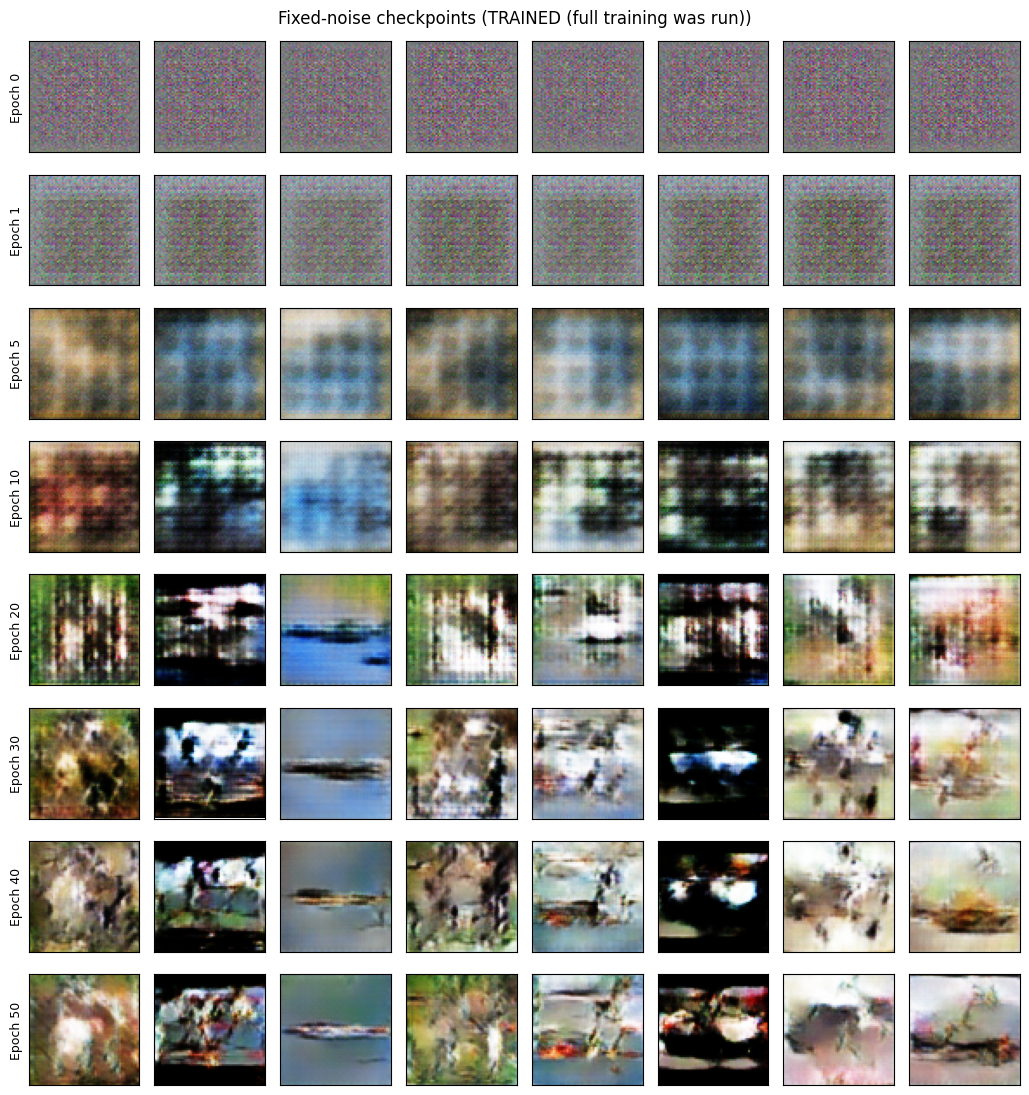

In [29]:
def plot_checkpoint_grid(snapshots, checkpoint_labels=SNAPSHOT_EPOCHS, samples_per_row=8):
    """Fixed-noise checkpoint grid, safe for the 8 requested checkpoint labels."""
    labels = [l for l in checkpoint_labels if l in snapshots]
    n = len(labels)
    fig, axes = plt.subplots(n, samples_per_row, figsize=(samples_per_row * 1.3, n * 1.4))
    axes = np.atleast_2d(axes)
    for r, label in enumerate(labels):
        imgs = snapshots[label].detach().cpu()
        imgs = ((imgs + 1) / 2).clamp(0, 1)
        for c in range(samples_per_row):
            ax = axes[r, c]
            if c < imgs.shape[0]:
                ax.imshow(imgs[c].permute(1, 2, 0).numpy())
            ax.set_xticks([]); ax.set_yticks([])
        axes[r, 0].set_ylabel(f"Epoch {label}", fontsize=9)
    fig.suptitle("Fixed-noise checkpoints (%s)" % history_label)
    plt.tight_layout()
    plt.show()


plot_checkpoint_grid(snapshots)

## 20. Real vs Fake

Side-by-side comparison of real STL-10 images and generated samples
(untrained demo images if `RUN_TRAINING=False`). Inspect:

- color structure and background coherence,
- rough object shapes vs natural objects,
- local textures, diversity across the batch,
- unrealistic artifacts.

Learn to evaluate samples *visually* — do not assume the network succeeded automatically.

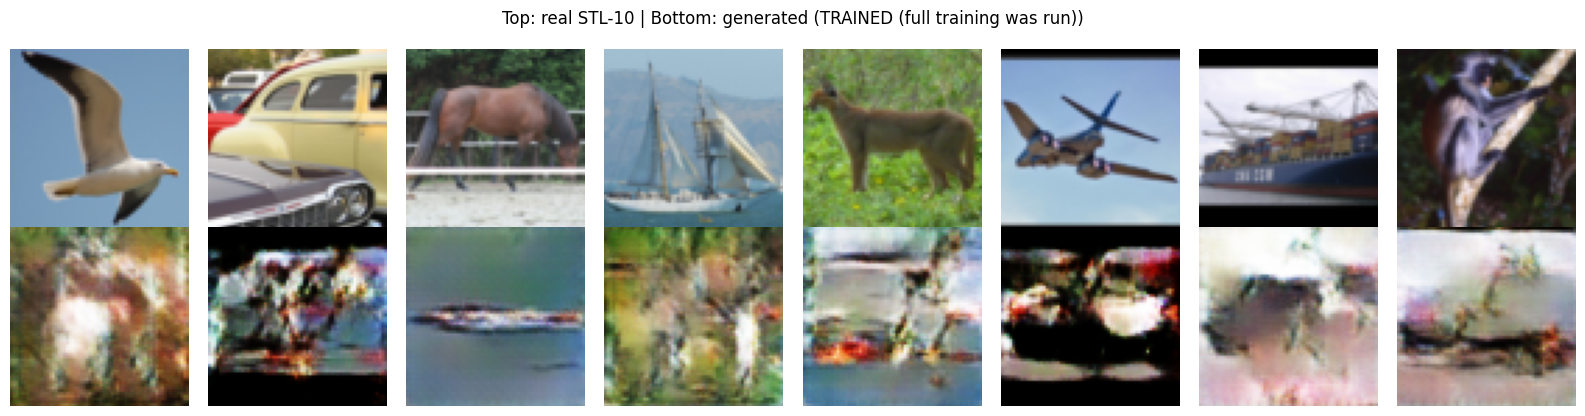

In [30]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.2))
real_imgs = ((real_batch[:8] + 1) / 2).clamp(0, 1)
fake_imgs = ((snapshots[max(SNAPSHOT_EPOCHS)] + 1) / 2).clamp(0, 1)[:8]
for c in range(8):
    axes[0, c].imshow(real_imgs[c].permute(1, 2, 0).numpy()); axes[0, c].axis("off")
    axes[1, c].imshow(fake_imgs[c].permute(1, 2, 0).numpy()); axes[1, c].axis("off")
axes[0, 0].set_ylabel("Real", fontsize=11); axes[1, 0].set_ylabel("Fake", fontsize=11)
fig.suptitle("Top: real STL-10 | Bottom: generated (%s)" % history_label)
plt.tight_layout()
plt.show()

## 21. Loss Visualization

GAN losses are **not** supervised losses: they measure performance against the
*current* moving opponent. They may oscillate, rise, or fall without directly
matching visual quality.

> Generated samples and discriminator diagnostics are always necessary alongside loss curves.

(When `RUN_TRAINING=False`, histories contain demo `NaN` values, and the plot
displays an explanatory label.)

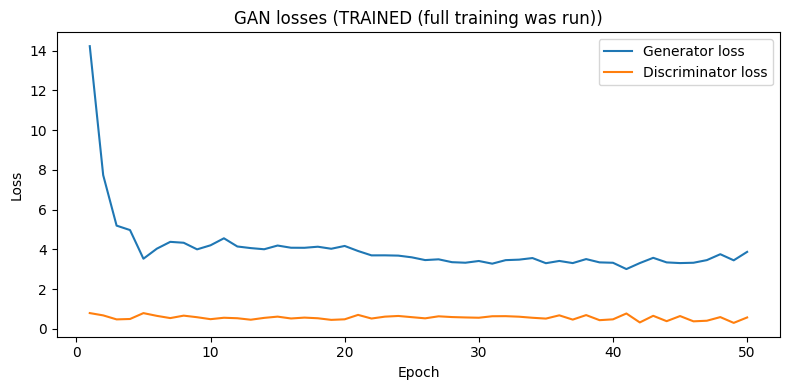

In [31]:
plt.figure(figsize=(8, 4))
if not all(np.isnan(generator_losses)):
    epochs_axis = range(1, EPOCHS + 1)
    plt.plot(epochs_axis, generator_losses, label="Generator loss")
    plt.plot(epochs_axis, discriminator_losses, label="Discriminator loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
else:
    plt.text(0.5, 0.5, "No training run (RUN_TRAINING=False)\nlosses are demo NaN placeholders",
             ha="center", va="center", transform=plt.gca().transAxes)
plt.title("GAN losses (%s)" % history_label)
plt.tight_layout()
plt.show()

## 22. Discriminator Diagnostics

We track D's average probability for real and fake images:

- **D(real) near 1**: D is confident real images are real.
- **D(fake) near 0**: D is confident fake images are fake.
- **Both become less extreme**: the game is becoming less trivial — G fools D more often.

There is no single ideal curve; interpret diagnostics alongside generated images.

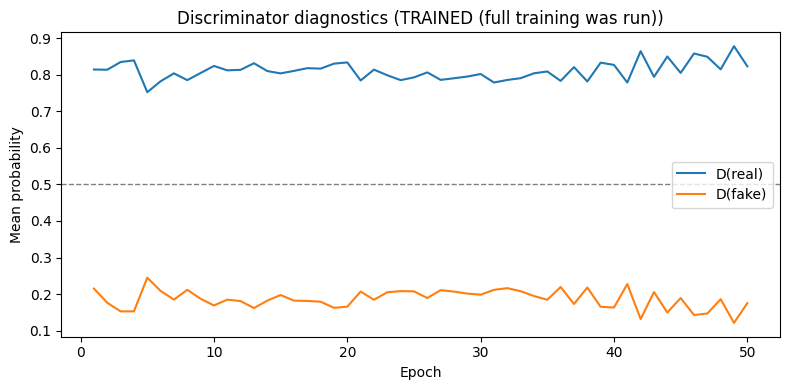

In [32]:
plt.figure(figsize=(8, 4))
if not all(np.isnan(discriminator_real_scores)):
    epochs_axis = range(1, EPOCHS + 1)
    plt.plot(epochs_axis, discriminator_real_scores, label="D(real)")
    plt.plot(epochs_axis, discriminator_fake_scores, label="D(fake)")
    plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    plt.xlabel("Epoch"); plt.ylabel("Mean probability"); plt.legend()
else:
    plt.text(0.5, 0.5, "No training run (RUN_TRAINING=False)\ndiagnostics are demo placeholders",
             ha="center", va="center", transform=plt.gca().transAxes)
plt.title("Discriminator diagnostics (%s)" % history_label)
plt.tight_layout()
plt.show()

## 23. Latent Interpolation

Linear interpolation between two random latent vectors:

$$z_lpha = (1 - lpha)\,z_1 + lpha\,z_2, \quad lpha = 0, 0.1, 0.2, \ldots, 1.0$$

We generate and display the 11 images in a single row. Latent interpolation
lets us inspect whether nearby points produce *gradual* visual transitions.
Semantic smoothness is **not guaranteed** — it is an empirical property to observe.

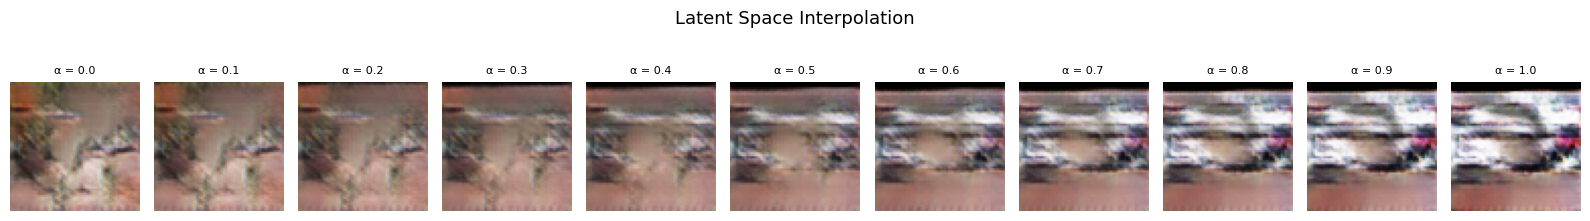

Generator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh(

In [34]:
# Switch Generator to evaluation mode
# Important because the Generator contains BatchNorm layers.
G.eval()

z1 = torch.randn(1, LATENT_DIM, device=DEVICE)
z2 = torch.randn(1, LATENT_DIM, device=DEVICE)

alphas = np.linspace(0, 1, 11)

interpolated = []

with torch.no_grad():
    for alpha in alphas:
        # Linear interpolation between z1 and z2
        z_alpha = (1 - alpha) * z1 + alpha * z2

        # Generate one image
        image = G(z_alpha)

        interpolated.append(image)

# [11, 3, 64, 64]
interpolated = torch.cat(interpolated, dim=0)

# Convert from [-1, 1] back to [0, 1]
imgs = ((interpolated + 1) / 2).clamp(0, 1)

# Plot
fig, axes = plt.subplots(
    1,
    len(alphas),
    figsize=(16, 2.5)
)

for i, ax in enumerate(axes):
    ax.imshow(
        imgs[i].permute(1, 2, 0).cpu().numpy()
    )

    ax.set_title(
        f"α = {alphas[i]:.1f}",
        fontsize=8
    )

    ax.axis("off")

fig.suptitle(
    "Latent Space Interpolation",
    fontsize=13
)

plt.tight_layout()
plt.show()

# Return to training mode if you will train again
G.train()

## 24. Compare Latent Interpolation With Vanilla GAN

Conceptual (empirical) comparison (independent of any Notebook 04 files):

| Aspect | Vanilla GAN (MLP) | DCGAN (convolutional) |
|---|---|---|
| Latent mapping | vector -> flat pixels | vector -> spatial feature maps |
| Sample structure | often incoherent locally | locally coherent patches |
| Smoothness | can jump abruptly between unrelated outputs | gradual changes often more visible |
| Visual detail | blurry / noisy | textures and edges emerge |
| Spatial coherence | weak (no neighborhood concept) | stronger (convolutions share locality) |

We do not claim DCGAN *always* produces smoother latent spaces — this is an
empirical comparison.

## 25. Random Samples

We generate a larger collection (64 random samples) and inspect:

- **Diversity**: are many samples clearly different?
- **Quality**: do they contain recognizable structure?
- **Repetition**: are many samples nearly identical?

Repetition here is the primary visual symptom of mode collapse.

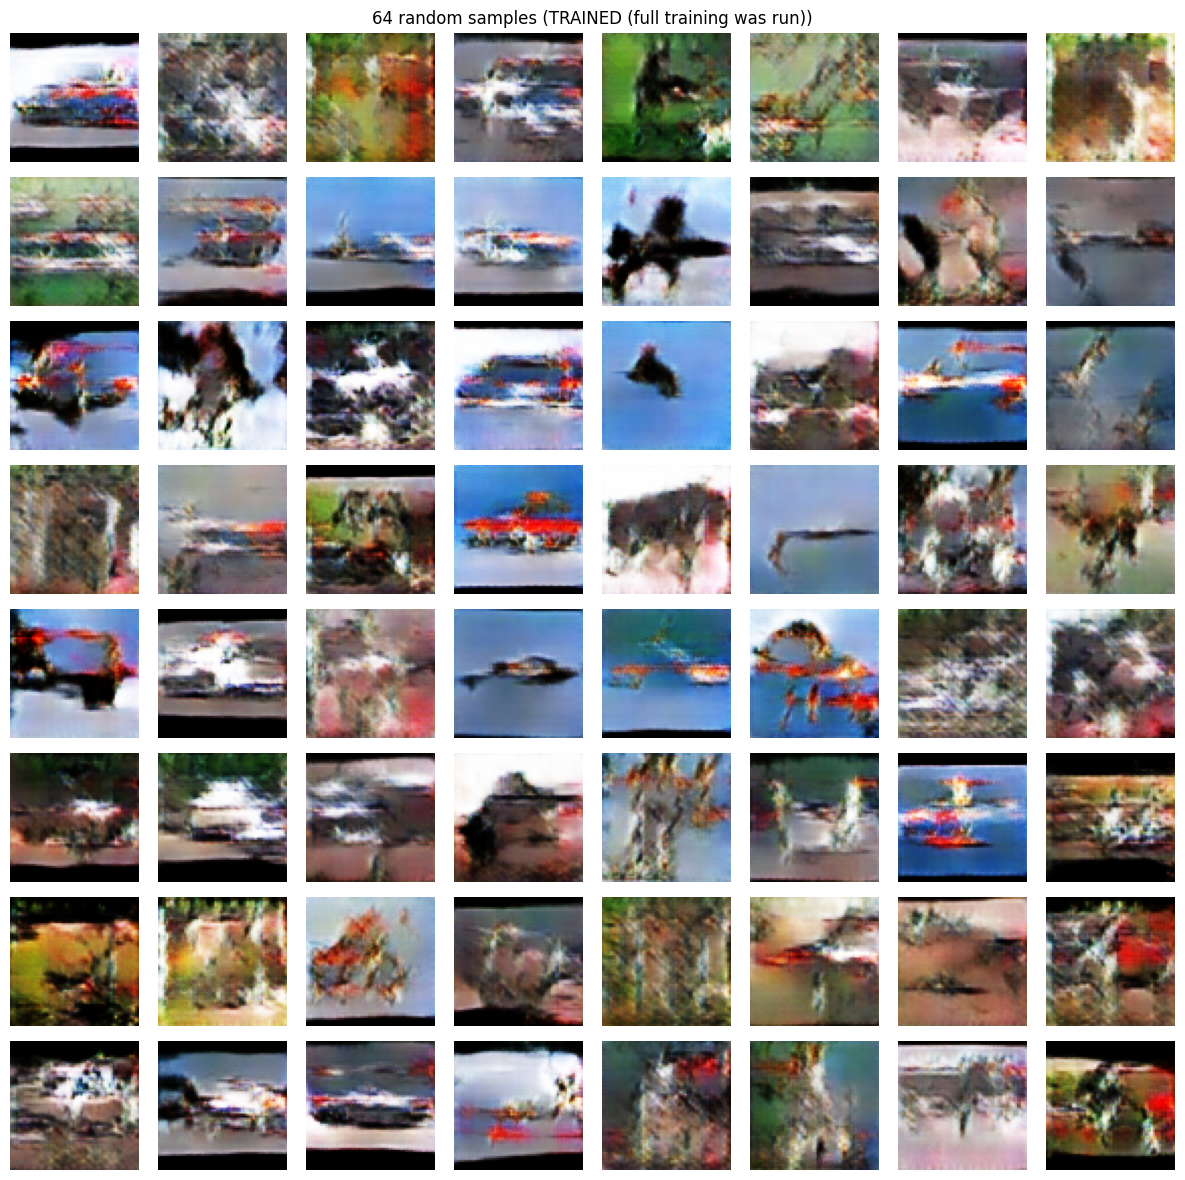

In [39]:
random_samples = generate_samples(G, 64)
show_images(random_samples, title=f"64 random samples ({history_label})", nrow=8, figsize=(12, 12))

## 26. Mode Collapse

> **Mode collapse** occurs when many different latent vectors produce very similar outputs.

```text
z1 ──┐
z2 ──┤
z3 ──┼──>  very similar images
z4 ──┘
```

Why it happens: if the Generator finds an image that fools the Discriminator,
it has strong gradient incentive to keep producing variants of that same
winning image instead of covering all modes (e.g. all 10 STL-10 classes).

Inspect the 64 samples above: if many look alike, you are observing mode collapse.

## 27. Image Artifacts

Common GAN artifacts:

- **Checkerboard patterns**: caused by overlapping transposed-convolution kernels.
- **Unnatural textures / weird colors**: G exploits high frequencies that D did not penalize.
- **Distorted geometry**: objects missing parts or blending into backgrounds.
- **Repeated motifs**: G repeating a local pattern across the image.

No single cause explains every artifact — they arise from the interaction of
upsampling, receptive field, and the adversarial loss.

## 28. Unstable Training

```text
Generator changes -> Discriminator adapts -> Generator adapts again -> Discriminator adapts again
```

This dynamic feedback loop is why GAN optimization fundamentally differs from
supervised learning:

- training may oscillate,
- visual quality can temporarily improve and then degrade,
- the loss may not converge to a neat minimum.

Use diagnostic plots (`D(real)`, `D(fake)`) and generated checkpoints together
to understand where the training state is.

## 29. Optional Visual Diagnostic — Nearest-Looking Generated Samples

Qualitative check: we sample a moderate collection of fake images and display
them so you can manually inspect whether samples appear repetitive, diverse, or
structured. No retrieval pipeline is needed — manual inspection is the most
direct educational tool.

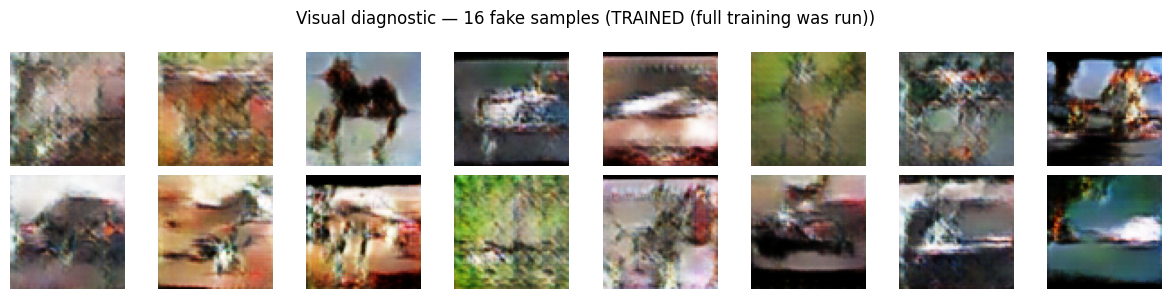

In [40]:
diagnostic_samples = generate_samples(G, 16)
show_images(diagnostic_samples, title=f"Visual diagnostic — 16 fake samples ({history_label})", nrow=8)

## 30. Why DCGAN Is Better Suited to Images

```text
Vanilla GAN:   Image -> Flatten -> Huge vector -> MLP
DCGAN:         Image -> Spatial feature maps -> Local patterns -> Hierarchical features
```

CNN advantages for images:

- **Spatial locality**: pixels close together are processed together.
- **Parameter sharing**: the same filter detects an edge anywhere in the image.
- **Hierarchical feature extraction**: shallow layers find edges/textures; deep layers find parts/objects.
- **Inductive bias**: the architecture assumes the 2D grid structure of images.

DCGAN is not universally superior to all modern generative models, but it is a
**much more natural baseline** for image generation than an MLP.

## 31. Architecture Visualization

### Generator (upsampling)

```text
z (100)
  |  Linear + reshape
[512, 4, 4]
  |  ConvTranspose2d(4, s=2, p=1) + BN + ReLU
[256, 8, 8]
  |  ConvTranspose2d(4, s=2, p=1) + BN + ReLU
[128, 16, 16]
  |  ConvTranspose2d(4, s=2, p=1) + BN + ReLU
[ 64, 32, 32]
  |  ConvTranspose2d(4, s=2, p=1) + Tanh
[  3, 64, 64] RGB Image
```

### Discriminator (feature extraction / downsampling)

```text
[  3, 64, 64] RGB Image
  |  Conv2d(4, s=2, p=1) + LeakyReLU(0.2)
[ 64, 32, 32]
  |  Conv2d(4, s=2, p=1) + BN + LeakyReLU(0.2)
[128, 16, 16]
  |  Conv2d(4, s=2, p=1) + BN + LeakyReLU(0.2)
[256,  8,  8]
  |  Conv2d(4, s=2, p=1) + BN + LeakyReLU(0.2)
[512,  4,  4]
  |  Flatten + Linear
1 logit
```

## 32. DCGAN Design Principles Summary

| Component | Role |
|---|---|
| `ConvTranspose2d` | Increase spatial resolution (learned upsampling) |
| `Conv2d` | Extract spatial features and downsample |
| `BatchNorm` | Help stabilize intermediate activations |
| `ReLU` | Nonlinearity in Generator |
| `LeakyReLU` | Nonlinearity in Discriminator (avoids dead neurons) |
| `Tanh` | Produces output roughly in `[-1, 1]` |
| `BCEWithLogitsLoss` | Stable binary classification loss (combines Sigmoid + BCE) |

## 33. Comparison With Vanilla GAN

| Property | Vanilla GAN | DCGAN |
|---|---|---|
| Generator | MLP | ConvTranspose2d |
| Discriminator | MLP | Conv2d |
| Image handling | Flattened vectors | Spatial structure |
| Main inductive bias | Fully connected | Convolutional |
| Spatial hierarchy | Weak | Strong |
| Image suitability | Basic baseline | More natural |

```text
Vanilla GAN teaches the adversarial mechanism.
DCGAN adds image-aware architecture.
```

## 34. Final Mental Model

1. Vanilla GAN treats an image mostly as a vector.
2. DCGAN treats an image as a spatial structure.
3. The Generator starts from a latent vector.
4. Transposed convolutions progressively increase resolution.
5. The Discriminator uses convolutions to extract spatial features.
6. BatchNorm can help maintain useful activation distributions.
7. ReLU is commonly used in the Generator.
8. LeakyReLU is commonly used in the Discriminator.
9. Latent interpolation lets us inspect the Generator's latent space.
10. GAN losses must be interpreted together with samples and D(real)/D(fake).
11. Mode collapse and artifacts are important failure modes to watch for.

## 35. Common Mistakes

1. **Incorrect Generator output size** — check `kernel_size`, `stride`, `padding` so resolution reaches `3 x 64 x 64`.
2. **Forgetting Tanh** — without `Tanh`, G outputs `(-inf, inf)` while data is normalized to `[-1, 1]`.
3. **Using Sigmoid with BCEWithLogitsLoss** — `BCEWithLogitsLoss` expects raw logits; applying Sigmoid twice breaks gradients.
4. **Wrong channel dimensions** — ensure channel sequence matches: `512 -> 256 -> 128 -> 64 -> 3`.
5. **Wrong spatial dimensions** — check `4 -> 8 -> 16 -> 32 -> 64` carefully.
6. **Forgetting `detach()` in the Discriminator step** — updating D must not backpropagate into G.
7. **Interpreting GAN loss alone** — GAN losses fluctuate; always look at samples and `D(real)` / `D(fake)`.
8. **Assuming latent arithmetic is guaranteed** — smooth interpolation is an empirical observation, not a theorem.

## 36. Try It Yourself

1. Change `LATENT_DIM` from `100` to `64`.
2. Change `BATCH_SIZE` to 32 or 128.
3. Increase or decrease the Generator feature-map sizes (`FEATURES_G = 32` or `128`).
4. Remove BatchNorm from one intermediate Generator layer and observe the effect.
5. Change the Discriminator feature-map sizes (`FEATURES_D = 32` or `128`).
6. Compare different learning rates (e.g. `1e-4` vs `5e-4`).
7. Train for more epochs (e.g. set `RUN_TRAINING = True` with `EPOCHS = 30` on a GPU).
8. Try different latent interpolation pairs `z1, z2`.
9. Generate 100 samples and inspect diversity across object classes.
10. Compare a few DCGAN samples with Vanilla GAN samples from Notebook 04.
11. Look for signs of mode collapse in the 64-sample grid.
12. Change the normalization strategy (e.g. to `[0, 1]` with Sigmoid) and see what happens.